In [1]:
!pip -q install opencv-python numpy pandas matplotlib seaborn scikit-learn scipy tqdm tensorflow

import os, glob, random
import numpy as np
import pandas as pd
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, skew, kurtosis

from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc

import tensorflow as tf
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.applications.efficientnet import preprocess_input

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Seed + Dataset path + Labeling**

In [3]:
SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)

sayem = "/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN"

img_exts = ("*.jpg","*.jpeg","*.png","*.bmp","*.webp")
all_imgs = []
for ext in img_exts:
    all_imgs += glob.glob(os.path.join(sayem, "**", ext), recursive=True)

def infer_label_from_path(p):
    lp = p.lower()
    pos_keys = ["jaundice","icteric","positive","pos","case","patient","affected","yellow"]
    neg_keys = ["normal","control","negative","neg","healthy","non"]
    if any(k in lp for k in pos_keys): return 1
    if any(k in lp for k in neg_keys): return 0
    return None

pairs = [(p, infer_label_from_path(p)) for p in all_imgs]
pairs = [(p,l) for p,l in pairs if l is not None]

print("Total labeled:", len(pairs))
print("Class counts:", np.bincount([l for _,l in pairs]))
print("Example:", pairs[:3])

Total labeled: 760
Class counts: [560 200]
Example: [('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1000).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1103).jpg', 0), ('/content/drive/MyDrive/MACHINE LEARNING_LAB_II/Final Project/NJN/NJN/normal/normal (1078).jpg', 0)]


**Seed + Dataset path + Labeling**

In [4]:
def extract_forehead_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.10*h); y2 = int(0.40*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_chest_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.40*h); y2 = int(0.80*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

def extract_abdomen_roi(img_bgr):
    h, w = img_bgr.shape[:2]
    x1 = int(0.25*w); x2 = int(0.75*w)
    y1 = int(0.60*h); y2 = int(0.92*h)
    roi = img_bgr[y1:y2, x1:x2]
    return roi if roi.size else None

**ROI functions (Forehead/Chest/Abdomen)**

In [5]:
def gray_world_white_balance(img_bgr):
    img = img_bgr.astype(np.float32)
    b, g, r = cv2.split(img)
    mb, mg, mr = np.mean(b), np.mean(g), np.mean(r)
    m = (mb + mg + mr) / 3.0
    b = b * (m / (mb + 1e-6))
    g = g * (m / (mg + 1e-6))
    r = r * (m / (mr + 1e-6))
    out = cv2.merge([b,g,r])
    return np.clip(out, 0, 255).astype(np.uint8)

def normalize_clahe_lab(roi_bgr, clip=2.5):
    lab = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2LAB)
    L, a, b = cv2.split(lab)
    clahe = cv2.createCLAHE(clipLimit=clip, tileGridSize=(8,8))
    L2 = clahe.apply(L)
    lab2 = cv2.merge([L2, a, b])
    return cv2.cvtColor(lab2, cv2.COLOR_LAB2BGR)

def preprocess_roi(roi_bgr):
    roi_bgr = gray_world_white_balance(roi_bgr)
    roi_bgr = normalize_clahe_lab(roi_bgr, clip=2.5)
    return roi_bgr

def skin_mask_hsv(roi_bgr):
    hsv = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2HSV)
    lower = np.array([0, 20, 40], dtype=np.uint8)
    upper = np.array([25, 255, 255], dtype=np.uint8)
    mask = cv2.inRange(hsv, lower, upper)
    k = np.ones((3,3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, k, iterations=1)
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, k, iterations=1)
    return mask

**Biomedical Feature Extraction (same for all ROIs)**

In [6]:
def masked_stats(channel, mask):
    vals = channel[mask==255].astype(np.float32)
    if vals.size < 30:
        return (np.nan,)*6
    return (
        float(np.mean(vals)),
        float(np.std(vals)),
        float(np.median(vals)),
        float(skew(vals)),
        float(kurtosis(vals)),
        float(np.percentile(vals, 90))
    )

def extract_features_from_roi(roi_bgr):
    roi_bgr = preprocess_roi(roi_bgr)
    mask = skin_mask_hsv(roi_bgr)
    if np.sum(mask==255) < 200:
        mask = np.ones(roi_bgr.shape[:2], dtype=np.uint8)*255

    roi_rgb = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB).astype(np.float32)
    R = roi_rgb[:,:,0]; G = roi_rgb[:,:,1]; B = roi_rgb[:,:,2]

    Rm, Rs, _, _, _, R90 = masked_stats(R, mask)
    Gm, Gs, _, _, _, G90 = masked_stats(G, mask)
    Bm, Bs, _, _, _, B90 = masked_stats(B, mask)

    ygi = float((Rm + Gm) / (Bm + 1e-6))
    r_over_b = float(Rm / (Bm + 1e-6))
    g_over_b = float(Gm / (Bm + 1e-6))
    rg_balance = float((Rm - Gm) / (Rm + Gm + 1e-6))

    denom = (Rm + Gm + Bm + 1e-6)
    r_ch = float(Rm / denom); g_ch = float(Gm / denom); b_ch = float(Bm / denom)

    hsv = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2HSV).astype(np.float32)
    H = hsv[:,:,0]; S = hsv[:,:,1]; V = hsv[:,:,2]
    Hm, _, _, _, _, _ = masked_stats(H, mask)
    Sm, _, _, _, _, _ = masked_stats(S, mask)
    Vm, Vs, _, _, _, _ = masked_stats(V, mask)

    Hvals = H[mask==255]
    hue_peak = float(np.argmax(np.histogram(Hvals, bins=18, range=(0,180))[0])) if Hvals.size > 30 else np.nan

    lab = cv2.cvtColor(roi_rgb.astype(np.uint8), cv2.COLOR_RGB2LAB).astype(np.float32)
    L = lab[:,:,0]; a = lab[:,:,1]; b = lab[:,:,2]
    Lm, _, _, _, _, _ = masked_stats(L, mask)
    am, _, _, _, _, _ = masked_stats(a, mask)
    bm, _, _, _, _, b90 = masked_stats(b, mask)

    bvals = b[mask==255]
    yellow_prop = float(np.mean(bvals > np.percentile(bvals, 75))) if bvals.size > 30 else np.nan

    feats = {
        "R_mean": Rm, "G_mean": Gm, "B_mean": Bm,
        "R_std": Rs, "G_std": Gs, "B_std": Bs,
        "R_p90": R90, "G_p90": G90, "B_p90": B90,

        "YGI": ygi,
        "R_over_B": r_over_b,
        "G_over_B": g_over_b,
        "RG_balance": rg_balance,
        "r_ch": r_ch, "g_ch": g_ch, "b_ch": b_ch,

        "H_mean": Hm, "S_mean": Sm, "V_mean": Vm,
        "V_std": Vs,
        "Hue_peak_bin": hue_peak,

        "L_mean": Lm, "a_mean": am, "Lab_b_mean": bm,
        "Lab_b_p90": b90,
        "yellow_prop": yellow_prop,
    }
    feats["YGI_x_b"] = feats["YGI"] * feats["Lab_b_mean"]
    return feats

**Biomedical Feature Extraction (same for all ROIs)**

In [7]:
def build_region_df(pairs, roi_fn, region_name="REGION"):
    rows = []
    failed = 0
    for p, label in tqdm(pairs, desc=f"Building {region_name} features"):
        img = cv2.imread(p)
        if img is None:
            failed += 1
            continue
        roi = roi_fn(img)
        if roi is None:
            failed += 1
            continue
        feats = extract_features_from_roi(roi)
        feats["label"] = int(label)
        feats["path"] = p
        rows.append(feats)
    df = pd.DataFrame(rows)
    print(f"{region_name} DF shape:", df.shape, "| Failed:", failed)
    print(df["label"].value_counts())
    return df

feat_df_forehead = build_region_df(pairs, extract_forehead_roi, "FOREHEAD")
feat_df_chest    = build_region_df(pairs, extract_chest_roi, "CHEST")
feat_df_abdomen  = build_region_df(pairs, extract_abdomen_roi, "ABDOMEN")

Building FOREHEAD features: 100%|██████████| 760/760 [02:02<00:00,  6.20it/s]


FOREHEAD DF shape: (760, 29) | Failed: 0
label
0    560
1    200
Name: count, dtype: int64


Building CHEST features: 100%|██████████| 760/760 [01:04<00:00, 11.78it/s]


CHEST DF shape: (760, 29) | Failed: 0
label
0    560
1    200
Name: count, dtype: int64


Building ABDOMEN features: 100%|██████████| 760/760 [00:51<00:00, 14.87it/s]

ABDOMEN DF shape: (760, 29) | Failed: 0
label
0    560
1    200
Name: count, dtype: int64


**Fusion (Classical) SVM**

Fusion shape: (760, 83)
Fusion label counts:
 label
0    560
1    200
Name: count, dtype: int64
FUSION 5-Fold CV AUC: [0.80625    0.78504464 0.68928571 0.78370536 0.8375    ]
FUSION Mean CV AUC: 0.7803571428571427

=== Fusion SVM (Classical) Report ===
              precision    recall  f1-score   support

           0      0.879     0.777     0.825       112
           1      0.528     0.700     0.602        40

    accuracy                          0.757       152
   macro avg      0.704     0.738     0.713       152
weighted avg      0.787     0.757     0.766       152

Confusion Matrix:
 [[87 25]
 [12 28]]
FUSION Test AUC: 0.7982142857142858


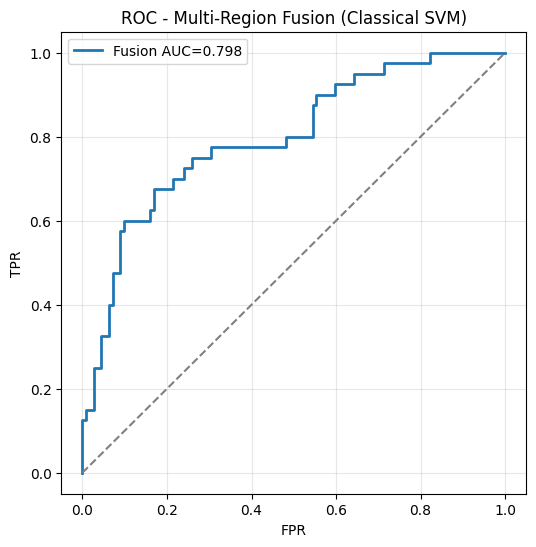

In [8]:
def prep_region(df, prefix):
    df = df.copy()
    keep = ["path","label"] + [c for c in df.columns if c not in ["path","label"] and np.issubdtype(df[c].dtype, np.number)]
    df = df[keep]
    feat_cols = [c for c in df.columns if c not in ["path","label"]]
    df = df.rename(columns={c: f"{prefix}_{c}" for c in feat_cols})
    return df

fh = prep_region(feat_df_forehead, "FH")
ch = prep_region(feat_df_chest, "CH")
ab = prep_region(feat_df_abdomen, "AB")

fusion = fh.merge(ch, on=["path","label"], how="inner").merge(ab, on=["path","label"], how="inner")
print("Fusion shape:", fusion.shape)
print("Fusion label counts:\n", fusion["label"].value_counts())

X = fusion.drop(columns=["path","label"])
y = fusion["label"].astype(int).values

X_imp = SimpleImputer(strategy="median").fit_transform(X)

svm = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(svm, X_imp, y, cv=cv, scoring="roc_auc")
print("FUSION 5-Fold CV AUC:", cv_auc)
print("FUSION Mean CV AUC:", cv_auc.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X_imp, y, test_size=0.2, random_state=42, stratify=y
)
svm.fit(X_train, y_train)
pred = svm.predict(X_test)
prob = svm.predict_proba(X_test)[:,1]

print("\n=== Fusion SVM (Classical) Report ===")
print(classification_report(y_test, pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("FUSION Test AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Fusion AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC - Multi-Region Fusion (Classical SVM)")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

**Hybrid (EfficientNet embeddings + classical fusion) SVM**

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Extracting deep embeddings (3 ROIs): 100%|██████████| 760/760 [20:28<00:00,  1.62s/it]


Failed embedding rows: 0
Hybrid X shape: (760, 3921)
HYBRID 5-Fold CV AUC: [0.91941964 0.89263393 0.90959821 0.91785714 0.91026786]
HYBRID Mean CV AUC: 0.909955357142857

=== Hybrid SVM Report ===
              precision    recall  f1-score   support

           0      0.901     0.973     0.936       112
           1      0.903     0.700     0.789        40

    accuracy                          0.901       152
   macro avg      0.902     0.837     0.862       152
weighted avg      0.901     0.901     0.897       152

Confusion Matrix:
 [[109   3]
 [ 12  28]]
HYBRID Test AUC: 0.9229910714285714


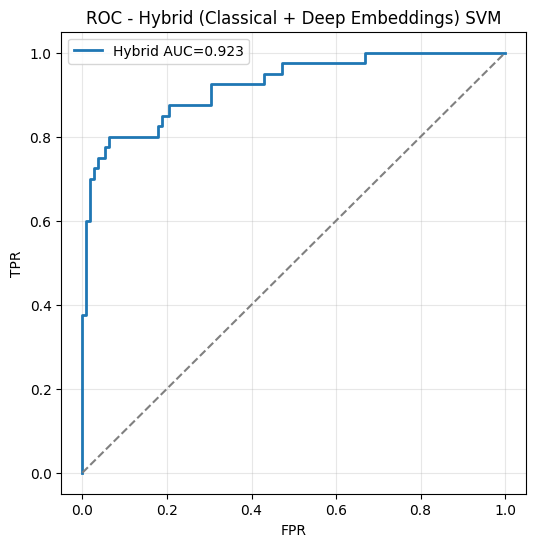

In [9]:
IMG_SIZE = 224
base = EfficientNetB0(weights="imagenet", include_top=False, pooling="avg",
                      input_shape=(IMG_SIZE, IMG_SIZE, 3))
base.trainable = False

def roi_to_tensor(roi_bgr):
    roi = cv2.cvtColor(roi_bgr, cv2.COLOR_BGR2RGB)
    roi = cv2.resize(roi, (IMG_SIZE, IMG_SIZE))
    x = roi.astype(np.float32)
    x = preprocess_input(x)
    return x

def get_embedding(path, roi_fn):
    img = cv2.imread(path)
    if img is None: return None
    roi = roi_fn(img)
    if roi is None: return None
    x = roi_to_tensor(roi)
    emb = base(np.expand_dims(x, 0), training=False).numpy().ravel()
    return emb

paths = fusion["path"].tolist()
labels = fusion["label"].astype(int).values

FH_emb, CH_emb, AB_emb = [], [], []
failed = 0

for p in tqdm(paths, desc="Extracting deep embeddings (3 ROIs)"):
    e1 = get_embedding(p, extract_forehead_roi)
    e2 = get_embedding(p, extract_chest_roi)
    e3 = get_embedding(p, extract_abdomen_roi)
    if (e1 is None) or (e2 is None) or (e3 is None):
        FH_emb.append(None); CH_emb.append(None); AB_emb.append(None)
        failed += 1
    else:
        FH_emb.append(e1); CH_emb.append(e2); AB_emb.append(e3)

print("Failed embedding rows:", failed)

keep_idx = [i for i,(a,b,c) in enumerate(zip(FH_emb, CH_emb, AB_emb)) if a is not None]
fusion_ok = fusion.iloc[keep_idx].reset_index(drop=True)
y_ok = fusion_ok["label"].astype(int).values

FH_mat = np.vstack([FH_emb[i] for i in keep_idx])
CH_mat = np.vstack([CH_emb[i] for i in keep_idx])
AB_mat = np.vstack([AB_emb[i] for i in keep_idx])

X_classical = fusion_ok.drop(columns=["path","label"])
X_classical = SimpleImputer(strategy="median").fit_transform(X_classical)

X_hybrid = np.hstack([X_classical, FH_mat, CH_mat, AB_mat])
print("Hybrid X shape:", X_hybrid.shape)

svm_hybrid = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf", probability=True, class_weight="balanced"))
])

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_auc = cross_val_score(svm_hybrid, X_hybrid, y_ok, cv=cv, scoring="roc_auc")
print("HYBRID 5-Fold CV AUC:", cv_auc)
print("HYBRID Mean CV AUC:", cv_auc.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y_ok, test_size=0.2, random_state=42, stratify=y_ok
)
svm_hybrid.fit(X_train, y_train)
pred = svm_hybrid.predict(X_test)
prob = svm_hybrid.predict_proba(X_test)[:,1]

print("\n=== Hybrid SVM Report ===")
print(classification_report(y_test, pred, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred))

fpr, tpr, _ = roc_curve(y_test, prob)
roc_auc = auc(fpr, tpr)
print("HYBRID Test AUC:", roc_auc)

plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"Hybrid AUC={roc_auc:.3f}", linewidth=2)
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel("FPR"); plt.ylabel("TPR")
plt.title("ROC - Hybrid (Classical + Deep Embeddings) SVM")
plt.legend(); plt.grid(alpha=0.3)
plt.show()

---------------------------
Goal: 0.5 not to fixed threshold

Youden J / F1 / Recall-target threshold

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, confusion_matrix, classification_report, precision_recall_curve
import numpy as np
import matplotlib.pyplot as plt

X_train, X_test, y_train, y_test = train_test_split(
    X_hybrid, y_ok, test_size=0.2, random_state=42, stratify=y_ok
)

svm_hybrid.fit(X_train, y_train)
proba = svm_hybrid.predict_proba(X_test)[:, 1]

**Threshold by Youden’s J (Best balanced screening threshold)**

In [13]:
fpr, tpr, thr = roc_curve(y_test, proba)
j = tpr - fpr
best_idx = np.argmax(j)
best_thr_j = thr[best_idx]

print("Best Threshold (Youden J):", best_thr_j)

pred_j = (proba >= best_thr_j).astype(int)
print("\n=== Report @ Youden Threshold ===")
print(classification_report(y_test, pred_j, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_j))

Best Threshold (Youden J): 0.4292092627962963

=== Report @ Youden Threshold ===
              precision    recall  f1-score   support

           0      0.929     0.938     0.933       112
           1      0.821     0.800     0.810        40

    accuracy                          0.901       152
   macro avg      0.875     0.869     0.872       152
weighted avg      0.901     0.901     0.901       152

Confusion Matrix:
 [[105   7]
 [  8  32]]


**Threshold by Max F1 (Best F1 trade-off)**

In [14]:
prec, rec, thr_pr = precision_recall_curve(y_test, proba)

# thr_pr has length = len(prec)-1
f1 = (2 * prec[:-1] * rec[:-1]) / (prec[:-1] + rec[:-1] + 1e-9)

best_idx_f1 = np.argmax(f1)
best_thr_f1 = thr_pr[best_idx_f1]

print("Best Threshold (Max F1):", best_thr_f1)
print("Best F1:", f1[best_idx_f1], "Precision:", prec[best_idx_f1], "Recall:", rec[best_idx_f1])

pred_f1 = (proba >= best_thr_f1).astype(int)
print("\n=== Report @ Max-F1 Threshold ===")
print(classification_report(y_test, pred_f1, digits=3))
print("Confusion Matrix:\n", confusion_matrix(y_test, pred_f1))

Best Threshold (Max F1): 0.5545897265603702
Best F1: 0.8108108103140979 Precision: 0.8823529411764706 Recall: 0.75

=== Report @ Max-F1 Threshold ===
              precision    recall  f1-score   support

           0      0.915     0.964     0.939       112
           1      0.882     0.750     0.811        40

    accuracy                          0.908       152
   macro avg      0.899     0.857     0.875       152
weighted avg      0.907     0.908     0.905       152

Confusion Matrix:
 [[108   4]
 [ 10  30]]


**Threshold to Achieve Target Recall (Screening mode)**

In [15]:
target_recall = 0.85 #change target

# find smallest threshold giving recall >= target
valid = np.where(rec[:-1] >= target_recall)[0]
if len(valid) == 0:
    print("No threshold reaches target recall. Max recall:", rec[:-1].max())
else:
    idx = valid[-1]  # highest threshold still meets target recall
    thr_recall = thr_pr[idx]
    print(f"Threshold for recall≥{target_recall}:", thr_recall)
    print("Precision at that threshold:", prec[idx], "Recall:", rec[idx])

    pred_r = (proba >= thr_recall).astype(int)
    print("\n=== Report @ Recall-Target Threshold ===")
    print(classification_report(y_test, pred_r, digits=3))
    print("Confusion Matrix:\n", confusion_matrix(y_test, pred_r))

Threshold for recall≥0.85: 0.2773379636587488
Precision at that threshold: 0.6181818181818182 Recall: 0.85

=== Report @ Recall-Target Threshold ===
              precision    recall  f1-score   support

           0      0.938     0.812     0.871       112
           1      0.618     0.850     0.716        40

    accuracy                          0.822       152
   macro avg      0.778     0.831     0.793       152
weighted avg      0.854     0.822     0.830       152

Confusion Matrix:
 [[91 21]
 [ 6 34]]


**Visualize metrics vs threshold (smooth curve)**

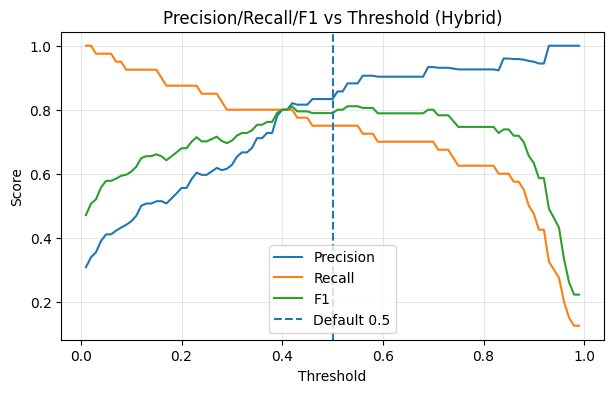

In [18]:
# Evaluate over grid
ths = np.linspace(0.01, 0.99, 99)
P, R, F1 = [], [], []

for t in ths:
    pr = (proba >= t).astype(int)
    cm = confusion_matrix(y_test, pr)
    tn, fp, fn, tp = cm.ravel()
    precision = tp/(tp+fp+1e-9)
    recall    = tp/(tp+fn+1e-9)
    f1score   = 2*precision*recall/(precision+recall+1e-9)
    P.append(precision); R.append(recall); F1.append(f1score)

plt.figure(figsize=(7,4))
plt.plot(ths, P, label="Precision")
plt.plot(ths, R, label="Recall")
plt.plot(ths, F1, label="F1")
plt.axvline(0.5, linestyle="--", label="Default 0.5")
plt.xlabel("Threshold"); plt.ylabel("Score")
plt.title("Precision/Recall/F1 vs Threshold (Hybrid)")
plt.grid(alpha=0.3); plt.legend()
plt.show()

The optimal classification threshold was selected using Youden’s J statistic (0.429), achieving 80% sensitivity and 82% precision with overall accuracy of 90%.